# Deel 2: Dynamica, Veerontwerp en Vliegwiel


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget


# ⚙️ Setup Cel
*Deze cel laadt automatisch de parameters en kinematische data (nokprofiel) uit het eerste deel, zodat we direct met de analyse kunnen starten.*


In [2]:
K_gewenst = 0.05
import numpy as np
import scipy.integrate as integrate
from scipy.fft import fft, fftfreq
import math

# Tijds- en snelheidsgegevens
T_cyclus = 0.5                     # Cyclustijd in s
omega = 2.0 * np.pi / T_cyclus     # Toerental in rad/s

# Nokgeometrie
R_0 = 0.050                        # Basisstraal nok in m
R_f = 0.015                        # Straal volgerwiel in m
e = 0.0                            # Excentriciteit volger in m

# Krachten, massa en wrijving
m_volger = 29.0                    # Equivalente massa in kg
mu = 0.1                           # Wrijvingscoëfficiënt
g = 9.81                           # Zwaartekrachtvalversnelling in m/s^2

# Veer en demper
zeta = 0.094                       # Relatieve demping
k_veer = 25000.0                   # Veerstijfheid in N/m
F_preload = 500.0                  # Mechanische voorspanning in N
c_demping = zeta * 2 * np.sqrt(k_veer * m_volger) # Absolute dempingsconstante in Ns/m

def cycloid_law(tau):
    y = tau - np.sin(2 * np.pi * tau) / (2 * np.pi)
    dy = 1.0 - np.cos(2 * np.pi * tau)
    ddy = 2 * np.pi * np.sin(2 * np.pi * tau)
    dddy = 4 * np.pi**2 * np.cos(2 * np.pi * tau)
    return y, dy, ddy, dddy

def poly5_law(tau):
    y = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    dy = 30 * tau**2 - 60 * tau**3 + 30 * tau**4
    ddy = 60 * tau - 180 * tau**2 + 120 * tau**3
    dddy = 60 - 360 * tau + 360 * tau**2
    return y, dy, ddy, dddy

def dwell_law(tau):
    zeros = np.zeros_like(tau)
    return zeros, zeros, zeros, zeros

theta_deg = np.linspace(0, 360, 3601)  
theta_rad = np.deg2rad(theta_deg)
time_array = theta_rad / omega

def calc_kinematics_for_profile(theta_array, segments):
    s, v, a, j = np.zeros_like(theta_array), np.zeros_like(theta_array), np.zeros_like(theta_array), np.zeros_like(theta_array)
    for (start_hoek, eind_hoek, start_lift, eind_lift, type_wet) in segments:
        beta = eind_hoek - start_hoek
        if beta <= 0: beta += 360.0 
        beta_rad = np.deg2rad(beta)
        h = eind_lift - start_lift
        shifted_deg = (theta_array - start_hoek) % 360.0
        mask = (shifted_deg >= 0) & (shifted_deg <= beta)
        tau = shifted_deg[mask] / beta
        if type_wet == 'cycloid': y, dy, ddy, dddy = cycloid_law(tau)
        elif type_wet == 'poly5': y, dy, ddy, dddy = poly5_law(tau)
        else: y, dy, ddy, dddy = dwell_law(tau)
        s[mask] = start_lift + h * y
        if type_wet != 'dwell':
            v[mask] = (h / beta_rad) * dy * omega
            a[mask] = (h / (beta_rad**2)) * ddy * (omega**2)
            j[mask] = (h / (beta_rad**3)) * dddy * (omega**3)
    return s, v, a, j

profiel_segmenten = [
    (10,   65,  0.0,   0.010, 'poly5'), 
    (65,   95,  0.010, 0.010, 'dwell'), 
    (95,  210,  0.010, 0.050, 'poly5'),
    (210, 350,  0.050, 0.0,   'poly5'), 
    (350,  10,  0.0,   0.0,   'dwell')  
]
s_profiel, v_profiel, a_profiel, j_profiel = calc_kinematics_for_profile(theta_deg, profiel_segmenten)

ds_dtheta = v_profiel / omega
d2s_dtheta2 = a_profiel / (omega**2)
s_base = np.sqrt((R_0 + R_f)**2 - e**2)
s_tot = s_base + s_profiel
alpha_rad = np.arctan((ds_dtheta - e) / s_tot)

X_pitch = s_tot * np.sin(theta_rad) + e * np.cos(theta_rad)
Y_pitch = s_tot * np.cos(theta_rad) - e * np.sin(theta_rad)
X_nok = X_pitch - R_f * np.sin(theta_rad - alpha_rad)
Y_nok = Y_pitch - R_f * np.cos(theta_rad - alpha_rad)



### 5. Inverse Dynamica: Krachtenbalans

Via d'Alembert's principe schrijven we de evenwichtsvergelijking in de bewegingsrichting van de volger:

$$F_{nok,vert} = F_{inertie} + F_{demping} + F_{zwaartekracht} + F_{veer} + F_{extern}$$

met:
- $F_{inertie} = m \cdot \ddot{s}$
- $F_{demping} = c \cdot \dot{s}$
- $F_{zwaartekracht} = m \cdot g$
- $F_{veer} = k \cdot s + F_{preload}$
- $F_{extern}$: opgelegde productiekracht

De **normaalkracht** (loodrecht op het nokoppervlak) en **wrijvingskracht** (langs het oppervlak) volgen dan:

$$F_{normaal} = \frac{F_{nok,vert}}{\cos(\alpha) - \mu \cdot \text{sgn}(\dot{s}) \cdot \sin(\alpha)}$$

$$F_{wrijving} = \mu \cdot F_{normaal} \cdot |\tan(\alpha)| \cdot \text{sgn}(\dot{s})$$

> **Veerontwerp (mondelinge vraag):** Hoe kies je $F_{preload}$?
> De voorspanning moet **net groot genoeg** zijn zodat $F_{normaal} > 0$ overal in de cyclus (geen zweefgedrag). Te hoog kiezen is nefast: de normaalkracht stijgt onnodig, wat meer **wrijvingsverliezen** en een **grotere motorbelasting** geeft. In de praktijk kies je $F_{preload}$ zodat $\min(F_{normaal}) \approx 50{-}100$ N als veiligheidsmarge.


Beoordeling Veer Capaciteit:
 -> Normaalkracht analyse (meest laag gedaalde drukwaarde): 784.49 N
 -> Analytische conclusie: Het ontwerp is robuust. De veer verhindert structureel wegslaan van de volger.


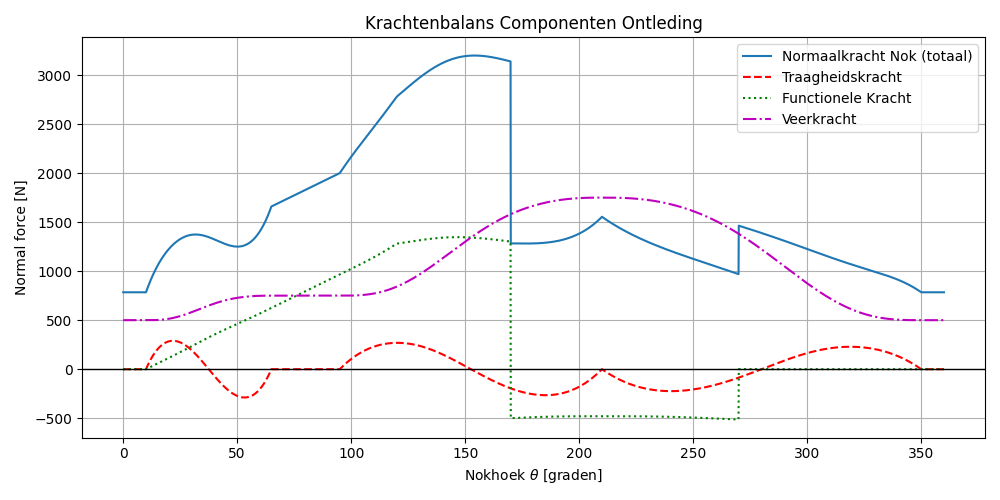

In [3]:
K_gewenst = 0.05
F_functioneel = np.zeros_like(theta_deg)
for i, th in enumerate(theta_deg):
    th_wrap = th % 360.0
    if 10 <= th_wrap < 120:
        F_functioneel[i] = (th_wrap - 10) / (120 - 10) * 1250.0
    elif 120 <= th_wrap < 170:
        F_functioneel[i] = 1250.0
    elif 170 <= th_wrap < 270:
        F_functioneel[i] = -480.0
    else:
        F_functioneel[i] = 0.0

F_in = m_volger * a_profiel
F_demping = c_demping * v_profiel
F_zwaar = m_volger * g
F_veer = k_veer * s_profiel + F_preload

# Neerwaartse kracht positief georiënteerd m.b.t het coördinatenstelsel van de theorie
F_som = F_in + F_demping + F_zwaar + F_veer + F_functioneel

F_nok_verticaal = np.zeros_like(theta_deg)
F_wrijving = np.zeros_like(theta_deg)
F_normaal_nok = np.zeros_like(theta_deg)

for i in range(len(theta_deg)):
    V_sign = np.sign(v_profiel[i]) if v_profiel[i] != 0 else 0
    noemer_wrijving = 1.0 - mu * np.abs(np.tan(alpha_rad[i])) * V_sign
    F_nok_verticaal[i] = F_som[i] / noemer_wrijving
    F_wrijving[i] = mu * F_nok_verticaal[i] * np.abs(np.tan(alpha_rad[i])) * V_sign
    F_normaal_nok[i] = F_nok_verticaal[i] / np.cos(alpha_rad[i])

min_contact_force = np.min(F_normaal_nok)
print("Beoordeling Veer Capaciteit:")
print(f" -> Normaalkracht analyse (meest laag gedaalde drukwaarde): {min_contact_force:.2f} N")
if min_contact_force <= 0:
    print(" -> Analytische conclusie: De theorethische veerstijfheid of haar pre-spanning schiet tekort. De volger zal ontkoppelen (zweefgedrag).")
else:
    print(" -> Analytische conclusie: Het ontwerp is robuust. De veer verhindert structureel wegslaan van de volger.")

fig3, ax_force = plt.subplots(figsize=(10, 5))
ax_force.plot(theta_deg, F_normaal_nok, label='Normaalkracht Nok (totaal)')
ax_force.plot(theta_deg, F_in / np.cos(alpha_rad), '--r', label='Traagheidskracht')
ax_force.plot(theta_deg, F_functioneel / np.cos(alpha_rad), ':g', label='Functionele Kracht')
ax_force.plot(theta_deg, F_veer / np.cos(alpha_rad), '-.m', label='Veerkracht')
ax_force.axhline(0, color='k', linewidth=1.0)
ax_force.set_ylabel('Normal force [N]')
ax_force.set_xlabel(r'Nokhoek $\theta$ [graden]')
ax_force.set_title('Krachtenbalans Componenten Ontleding')
ax_force.grid(True)
ax_force.legend()
plt.tight_layout()
plt.show()

### 6. Aandrijfvermogen en Vliegwielontwerp

Het **aandrijfkoppel** op de nok-as volgt uit virtuele arbeid:

$$M(\theta) = F_{nok,vert} \cdot \frac{ds}{d\theta}$$

Het **gemiddeld vermogen** is:
$$P_{gem} = \frac{1}{2\pi} \int_0^{2\pi} M(\theta)\,\omega\,d\theta$$

#### Vliegwiel

Het vliegwiel absorbeert de **energiefluctuatie** $\Delta E$ tussen het gemiddeld koppel en het werkelijk koppel:
$$I_{vliegwiel} = \frac{\Delta E}{K_{gewenst} \cdot \omega^2}$$

waarbij $K_{gewenst} = 0.05$ de maximale toelaatbare snelheidsfluctuatie als fractie van $\omega$ is.

> **Mondelinge vraag — "Wat als T_cyclus = 0.25s (2× sneller)?"**
> - Het geometrisch nokprofiel **verandert niet**: $s(\theta)$ is puur geometrisch
> - $\omega$ verdubbelt → versnellingen stijgen **kwadratisch** ($\ddot{s} \propto \omega^2$)
> - Inertiële krachten verdubbelen kwadratisch → motor moet **4× meer koppelvermogen** leveren
> - Het vliegwiel moet ook groter: $I \propto \omega^{-2}$ (paradoxaal: kleinere $I$ nodig, maar het koppel is groter)
> - **Beter alternatief?** Twee machines parallel → elk aan halve snelheid, kwart van de krachten


Analyse en Capaciteit Specificaties tbv Aandrijving:
 -> Gemiddeld Theorethisch Model Vermogen (P_gemiddeld)                : 113.15 W
 -> Analoog Nominale Koppel As-Belasting (M_gemiddeld)               : 9.00 Nm
 -> Maximale Fluctuatie Cyclus Uitslag op Energie (Delta E)          : 84.97 J
 -> Tolerantie Conform Berekend Component Vliegwiel Traagheid (I)    : 10.7614 kg·m^2


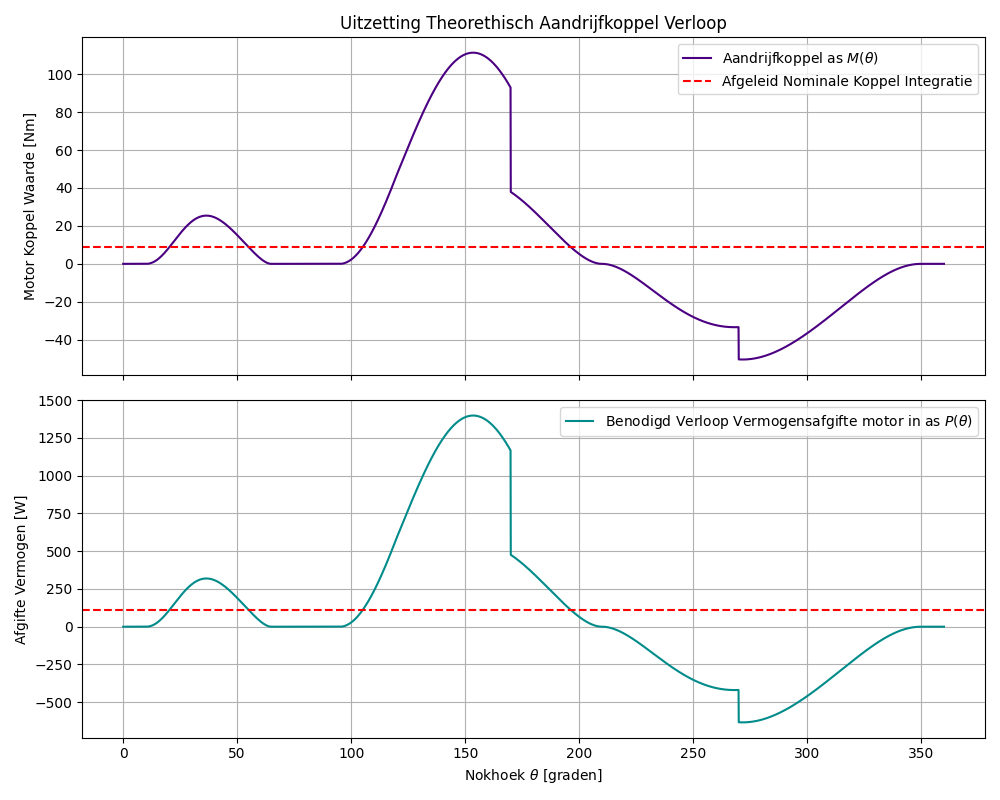

In [4]:
M_aandrijf = F_nok_verticaal * (v_profiel / omega)
P_aandrijf = M_aandrijf * omega

# Compatabiliteit verzekerd met gebruikmakend van 'trapezoid' in plaats van de NumPy 1.x specifieke 'trapz' afgeleiden, opdat er geen fout ontstaat bij moderne evaluatie pakketten NumPy 2.x
P_gemiddeld = np.trapezoid(P_aandrijf, theta_rad) / (2 * np.pi)
M_gemiddeld = P_gemiddeld / omega

dtheta_rad = theta_rad[1] - theta_rad[0]
E_fluct = np.cumsum((M_aandrijf - M_gemiddeld) * dtheta_rad)
Delta_E = np.max(E_fluct) - np.min(E_fluct)
I_vliegwiel = Delta_E / (K_gewenst * omega**2)

print("Analyse en Capaciteit Specificaties tbv Aandrijving:")
print(f" -> Gemiddeld Theorethisch Model Vermogen (P_gemiddeld)                : {P_gemiddeld:.2f} W")
print(f" -> Analoog Nominale Koppel As-Belasting (M_gemiddeld)               : {M_gemiddeld:.2f} Nm")
print(f" -> Maximale Fluctuatie Cyclus Uitslag op Energie (Delta E)          : {Delta_E:.2f} J")
print(f" -> Tolerantie Conform Berekend Component Vliegwiel Traagheid (I)    : {I_vliegwiel:.4f} kg·m^2")

fig4, (ax_torque, ax_power) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax_torque.plot(theta_deg, M_aandrijf, label=r'Aandrijfkoppel as $M(\theta)$', color='indigo')
ax_torque.axhline(M_gemiddeld, color='r', linestyle='--', label=r'Afgeleid Nominale Koppel Integratie')
ax_torque.set_ylabel('Motor Koppel Waarde [Nm]')
ax_torque.set_title('Uitzetting Theorethisch Aandrijfkoppel Verloop')
ax_torque.grid(True)
ax_torque.legend()

ax_power.plot(theta_deg, P_aandrijf, label=r'Benodigd Verloop Vermogensafgifte motor in as $P(\theta)$', color='darkcyan')
ax_power.axhline(P_gemiddeld, color='r', linestyle='--')
ax_power.set_ylabel('Afgifte Vermogen [W]')
ax_power.set_xlabel(r'Nokhoek $\theta$ [graden]')
ax_power.grid(True)
ax_power.legend()
plt.tight_layout()
plt.show()